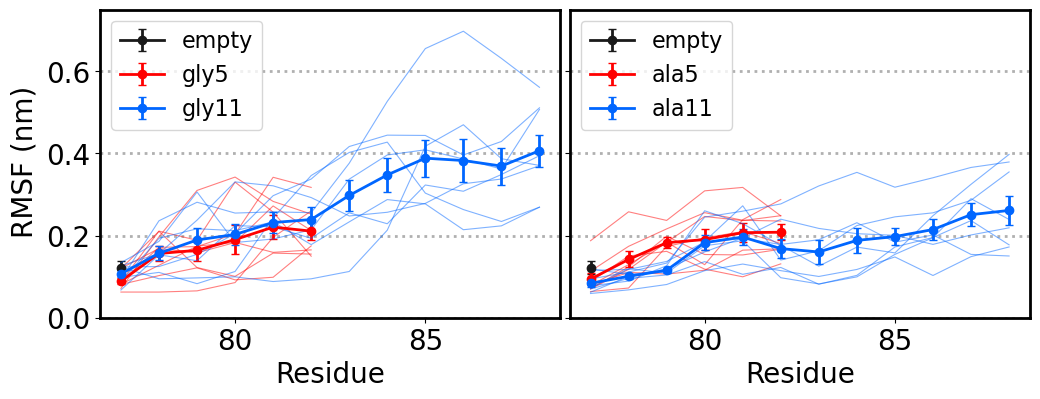

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import sem


plt.rcParams.update({'font.size': 20})

N_TRJ = 8
RESULTS = "../output_files/rmsf/"
SELECTION_CONFIG = {
    "peptide": {
        "xticks": (80, 85),
        "ylim": (0, 7.5),
        "yticks": (0, 2, 4, 6),
        "ytick_labels": (0.0, 0.2, 0.4, 0.6),
    },
}
SYSTEMS = {
    "GLY": [
        "empty",
        "gly5",
        "gly11",
    ],
    "ALA": [
        "empty",
        "ala5",
        "ala11",
    ]
}
COLORS = {
    "empty": "#1a1a1a",
    "gly5": "#ff0000",
    "gly11": "#0066ff",
    "ala5": "#ff0000",
    "ala11": "#0066ff",
}

for selection_name, config in SELECTION_CONFIG.items():
    fig, axs = plt.subplots(1, 2, sharey=True, figsize=(12, 4))
    for i, peptide in enumerate(SYSTEMS):
        for system in SYSTEMS[peptide]:
            data = []
            x = np.atleast_1d(np.loadtxt(f"{RESULTS}/{system}.0.{selection_name}.dat"))[0]
            for trj_index in range(N_TRJ):
                data.append(np.atleast_1d(np.loadtxt(f"{RESULTS}/{system}.{trj_index}.{selection_name}.dat")[1]))
            axs[i].plot(x, np.array(data).T, linewidth=0.8, color=COLORS[system], alpha=0.5)
            data_mean = np.mean(data, axis=0)
            data_sem = sem(data, axis=0)
            axs[i].errorbar(
                x,
                data_mean,
                yerr=data_sem,
                label=system,
                marker="o",
                color=COLORS[system],
                linewidth=2,
                capsize=3,
            )
        axs[i].grid(linewidth=2, axis="y", linestyle=":")
        axs[i].set_yticks(config["yticks"], labels=config["ytick_labels"])
        axs[i].set_xticks(config["xticks"])
        axs[i].set_ylim(config["ylim"])
        axs[i].spines[:].set_linewidth(2)
        axs[i].set_xlabel("Residue")
        axs[i].legend(fontsize=16, loc="upper left")
    plt.subplots_adjust(wspace=0.02)
    fig.text(0.05, 0.5, "RMSF (nm)", va="center", rotation="vertical")